In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS
from sac.trainer import HockeyTrainer

In [2]:
params = SB3_PARAMS
hidden_sizes = [256, 256]
params["alpha"] = 0.01
params["hidden_sizes"] = hidden_sizes

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/basic-{random_seed}"

In [6]:
trainer = HockeyTrainer(params)
opponent = h_env.BasicOpponent()

In [ ]:
# trainer.load(f"./results/test-{random_seed}-1596.pth")
# trainer.load(f"../checkpoint2/defense/results/SAC-Defense-0-3639.pth")

In [7]:
trainer.warmup(256)

In [45]:
max_timesteps = 1000
new_episodes = 1500
log_interval = 20
train_interval = 20

In [ ]:
trainer.train(opponent, new_episodes, train_interval, log_interval, max_timesteps)

  1520: Reward:   -3.905 Winrate:    0.425
  1540: Reward:   -4.316 Winrate:    0.375
  1560: Reward:   -5.067 Winrate:    0.375
  1580: Reward:   -3.874 Winrate:    0.450
  1600: Reward:   -3.361 Winrate:    0.450
  1620: Reward:   -0.659 Winrate:    0.575
  1640: Reward:   -6.103 Winrate:    0.350
  1660: Reward:   -5.887 Winrate:    0.375
  1680: Reward:   -4.319 Winrate:    0.425
  1700: Reward:   -2.141 Winrate:    0.525
  1720: Reward:   -4.087 Winrate:    0.450
  1740: Reward:   -7.757 Winrate:    0.275
  1760: Reward:   -7.886 Winrate:    0.300
  1780: Reward:   -6.377 Winrate:    0.300
  1800: Reward:   -3.207 Winrate:    0.475
  1820: Reward:   -7.026 Winrate:    0.325
  1840: Reward:    0.053 Winrate:    0.650
  1860: Reward:   -4.323 Winrate:    0.425
  1880: Reward:   -2.735 Winrate:    0.525
  1900: Reward:   -1.293 Winrate:    0.575
  1920: Reward:   -5.196 Winrate:    0.425
  1940: Reward:   -2.478 Winrate:    0.550
  1960: Reward:   -1.407 Winrate:    0.575
  1980: Rew

In [ ]:
rewards, scores = trainer.evaluate(opponent, 100, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

In [36]:
trainer.evaluate(opponent, render=True)

([-1.3216584712697397,
  -2.2679904177708017,
  8.896657485986088,
  8.509005430149431,
  9.17145468147821],
 [0, 0, 1, 1, 1])

In [37]:
trainer.reset()

In [38]:
trainer.save_agent(filepath)

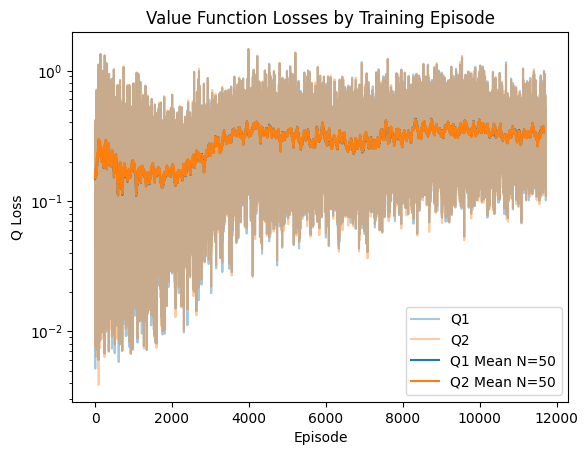

In [39]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

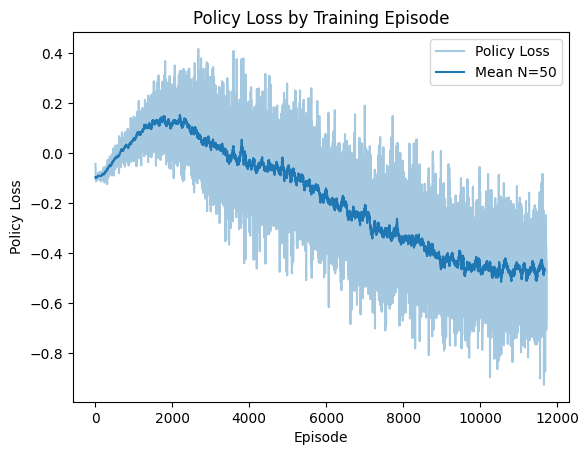

In [40]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

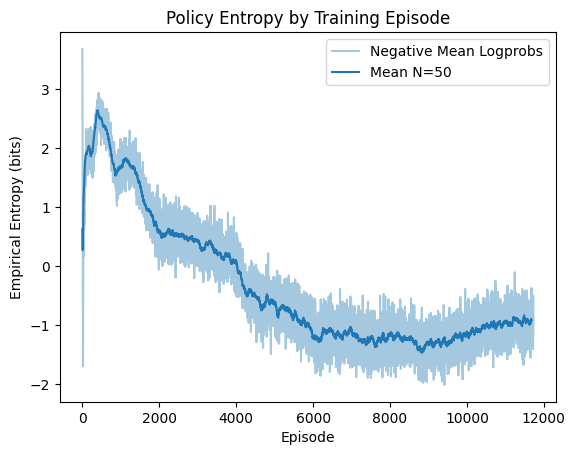

In [41]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

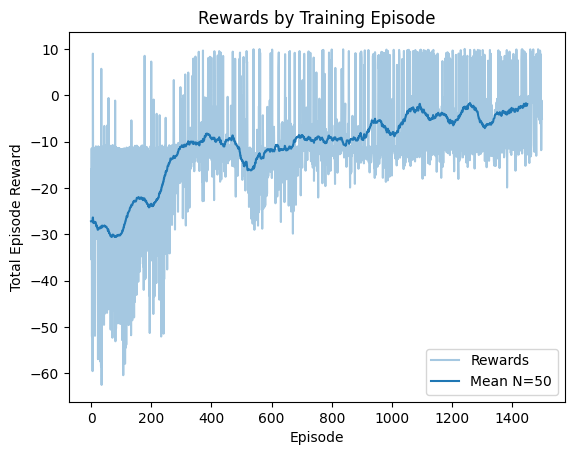

In [42]:
plot_rewards(trainer.logs["Rewards"], "./results")

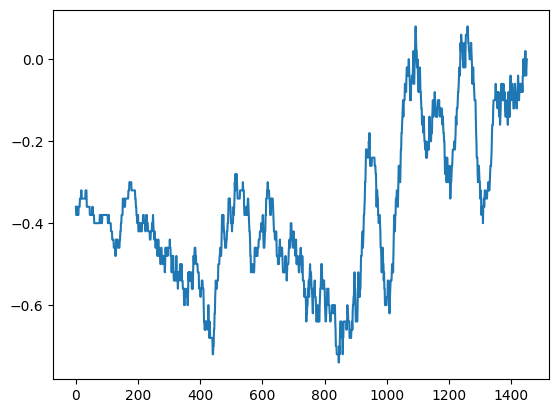

In [43]:
plt.plot(running_mean(trainer.logs["Scores"], 50))

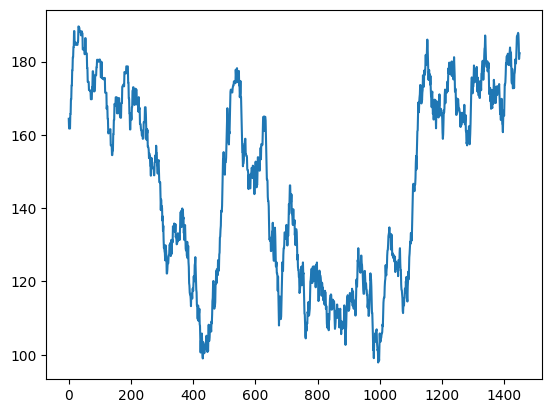

In [44]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))